In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/ayeshashoaib123/coffee-recommendations/coffee_recommendation_dataset.csv


Pipeline
--------
1. Load the labeled dataset (customer_text + attribute columns + the
   drink that was recommended).
2. NLP layer:
     a. Clean/normalize customer text.
     b. Vectorize it with TF-IDF (the model's "understanding" of free text).
     c. A rule-based extractor pulls structured signals out of new,
        unseen text at inference time (temperature mentioned, desired
        temperature, sweetness, coffee strength) -- this is the part
        that prints "Temperature: Hot / Preference: Cold / ..." the way
        a barista would think it through.
3. ANN layer: a small feed-forward neural network (Keras) takes the
   TF-IDF vector + one-hot encoded attributes and predicts the drink,
   with a softmax confidence score.
4. `ai_barista(text)` ties it together and prints a friendly
   recommendation like:  "🧊🍦 Iced Vanilla Latte — 94% match"


In [2]:
import re
import json
import numpy as np
import pandas as pd
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(42)
np.random.seed(42)



In [3]:
DATA_PATH = "/kaggle/input/datasets/ayeshashoaib123/coffee-recommendations/coffee_recommendation_dataset.csv"
MODEL_SAVE_PATH = 'kaggle/working/best_model.keras'

COLS = {
    "text": "customer_text",
    "temperature": "temperature",   # Iced / Hot
    "sweetness": "sweetness",       # High / Medium / Low
    "strength": "strength",         # Strong / Medium / Mild
    "milk": "milk",                 # Yes / No
    "creaminess": "creaminess",     # High / Medium / Low
    "label": "recommended_drink",
}

ATTRIBUTE_COLS = ["temperature", "sweetness", "strength", "milk", "creaminess"]

DRINK_EMOJIS = {
    "Iced Vanilla Latte":   "🧊🍦",
    "Americano":            "☕",
    "Salted Caramel Latte": "🍮☕",
    "Iced Latte":           "🧊☕",
    "Mocha":                "🍫☕",
    "Cappuccino":           "☕🫧",
}
DEFAULT_EMOJI = "☕"

In [4]:
def load_data(path):
    df = pd.read_csv(path)
    print("Loaded", len(df), "rows. Columns found:", list(df.columns))
    missing = [c for c in COLS.values() if c not in df.columns]
    if missing:
        raise ValueError("Expected columns " + str(missing) + " not found. Update COLS to match: " + str(list(df.columns)))
    df = df.dropna(subset=[COLS["text"], COLS["label"]]).reset_index(drop=True)
    return df


def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


NEGATIONS = {"not", "no", "don't", "dont", "isn't", "isnt", "without", "n't"}


def _is_negated(tokens, idx, window=3):
    start = max(0, idx - window)
    return any(tok in NEGATIONS for tok in tokens[start:idx])


def extract_attributes(raw_text):
    text = clean_text(raw_text)
    tokens = text.split()

    result = {
        "Temperature": None,
        "Preference": None,
        "Sweetness": "Medium",
        "Coffee strength": "Medium",
        "Milk": "Yes",
    }

    weather_match = re.search(r"\bit'?s\s+(?:really\s+|very\s+)?(hot|cold|warm|chilly|cool)\b", text)
    if weather_match:
        w = weather_match.group(1)
        result["Temperature"] = "Hot" if w in ("hot", "warm") else "Cold"

    pref_words = {"cold": "Cold", "iced": "Cold", "chilled": "Cold", "icy": "Cold", "hot": "Hot", "warm": "Hot"}
    for i, tok in enumerate(tokens):
        if tok in pref_words:
            if weather_match and tok in weather_match.group(0):
                continue
            result["Preference"] = pref_words[tok]

    if result["Preference"] is None:
        result["Preference"] = result["Temperature"] or "Hot"
    if result["Temperature"] is None:
        result["Temperature"] = result["Preference"]

    for i, tok in enumerate(tokens):
        if tok in ("sweet", "sweeter", "sugary"):
            result["Sweetness"] = "Low" if _is_negated(tokens, i) else "High"
        elif tok in ("unsweetened", "bitter"):
            result["Sweetness"] = "Low"

    for i, tok in enumerate(tokens):
        if tok in ("strong", "bold", "intense", "powerful"):
            result["Coffee strength"] = "Low" if _is_negated(tokens, i) else "High"
        elif tok in ("mild", "gentle", "light", "smooth"):
            if not _is_negated(tokens, i):
                result["Coffee strength"] = "Low"

    if re.search(r"\b(without milk|no milk|black|dairy[- ]free)\b", text):
        result["Milk"] = "No"

    return result


def map_extracted_to_schema(extracted):
    temp_map = {"Cold": "Iced", "Hot": "Hot"}
    strength_map = {"Low": "Mild", "Medium": "Medium", "High": "Strong"}
    sweet_map = {"Low": "Low", "Medium": "Medium", "High": "High"}

    return {
        "temperature": temp_map.get(extracted["Preference"], "Hot"),
        "sweetness": sweet_map.get(extracted["Sweetness"], "Medium"),
        "strength": strength_map.get(extracted["Coffee strength"], "Medium"),
        "milk": extracted["Milk"],
        "creaminess": "High" if extracted["Sweetness"] == "High" else "Medium",
    }

In [5]:
# 4. FEATURE ENGINEERING (fit on training data)
# ------------------------------------------------------------------------
def build_features(df):
    df["clean_text"] = df[COLS["text"]].apply(clean_text)

    tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
    X_text = tfidf.fit_transform(df["clean_text"]).toarray()

    attr_df = df[[COLS[c] for c in ATTRIBUTE_COLS]].astype(str)
    attr_df.columns = ATTRIBUTE_COLS
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    X_attrs = ohe.fit_transform(attr_df)

    X = np.hstack([X_text, X_attrs])

    label_encoder = LabelEncoder()
    y_int = label_encoder.fit_transform(df[COLS["label"]])
    y = tf.keras.utils.to_categorical(y_int)

    return X, y, tfidf, ohe, label_encoder


In [6]:
# 5. ANN MODEL
# ------------------------------------------------------------------------
def build_ann(input_dim, num_classes):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model


In [7]:
# 6. TRAINING PIPELINE
# ------------------------------------------------------------------------
def train_pipeline(data_path=DATA_PATH):
    df = load_data(data_path)
    X, y, tfidf, ohe, label_encoder = build_features(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = build_ann(input_dim=X.shape[1], num_classes=y.shape[1])
    early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

    model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=60,
        batch_size=32,
        callbacks=[early_stop],
        verbose=2,
    )
    y_pred = model.predict(X_test, verbose=0)
    y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred, axis=1))
    y_test_labels = label_encoder.inverse_transform(np.argmax(y_test, axis=1))

    print(f"\nTest accuracy: {accuracy_score(y_test_labels, y_pred_labels):.3f}")
    print("\nClassification report:")
    print(classification_report(y_test_labels, y_pred_labels))

    # Persist everything needed for inference
    model.save("ai_barista_ann.keras")
    joblib.dump(tfidf, "tfidf_vectorizer.joblib")
    joblib.dump(ohe, "attribute_encoder.joblib")
    joblib.dump(label_encoder, "label_encoder.joblib")
    print("\nSaved model + preprocessors to disk.")

    return model, tfidf, ohe, label_encoder


In [8]:
# 7. INFERENCE -- the "AI Barista" experience
# ------------------------------------------------------------------------
def ai_barista(text, model, tfidf, ohe, label_encoder, verbose=True):
    extracted = extract_attributes(text)
    mapped = map_extracted_to_schema(extracted)

    if verbose:
        print(f'Customer: "{text}"')
        print("\nExtracted:")
        print(f"  Temperature     : {extracted['Temperature']}")
        print(f"  Preference      : {extracted['Preference']}")
        print(f"  Sweetness       : {extracted['Sweetness']}")
        print(f"  Coffee strength : {extracted['Coffee strength']}")

    clean = clean_text(text)
    x_text = tfidf.transform([clean]).toarray()

    attr_row = pd.DataFrame([mapped])[ATTRIBUTE_COLS]
    x_attrs = ohe.transform(attr_row)

    x = np.hstack([x_text, x_attrs])
    probs = model.predict(x, verbose=0)[0]

    top_idx = int(np.argmax(probs))
    drink = label_encoder.inverse_transform([top_idx])[0]
    confidence = probs[top_idx] * 100

    emoji = DRINK_EMOJIS.get(drink, DEFAULT_EMOJI)
    result_line = f"{emoji} {drink} — {confidence:.0f}% match"

    if verbose:
        print(f"\n{result_line}")

    return {
        "extracted": extracted,
        "recommended_drink": drink,
        "confidence": round(float(confidence), 1),
        "display": result_line,
    }


In [9]:
# 8. MAIN
# ------------------------------------------------------------------------
if __name__ == "__main__":
    model, tfidf, ohe, label_encoder = train_pipeline(DATA_PATH)

    print("\n" + "=" * 60)
    print("DEMO")
    print("=" * 60)

    demo_text = (
        "It's really hot today. I want something cold and sweet "
        "but I don't want very strong coffee."
    )
    ai_barista(demo_text, model, tfidf, ohe, label_encoder)

    # A couple more example requests
    for t in [
        "I need a really strong black coffee to wake up",
        "Give me something chocolatey and creamy",
    ]:
        print("\n" + "-" * 60)
        ai_barista(t, model, tfidf, ohe, label_encoder)

Loaded 71 rows. Columns found: ['customer_text', 'temperature', 'sweetness', 'strength', 'milk', 'creaminess', 'recommended_drink']


I0000 00:00:1787580601.023197      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/60


I0000 00:00:1787580606.367341      68 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2/2 - 6s - 3s/step - accuracy: 0.1600 - loss: 2.4532 - val_accuracy: 0.1667 - val_loss: 2.4193
Epoch 2/60
2/2 - 0s - 42ms/step - accuracy: 0.2200 - loss: 2.4062 - val_accuracy: 0.3333 - val_loss: 2.3879
Epoch 3/60
2/2 - 0s - 39ms/step - accuracy: 0.2600 - loss: 2.3705 - val_accuracy: 0.0000e+00 - val_loss: 2.3666
Epoch 4/60
2/2 - 0s - 39ms/step - accuracy: 0.2800 - loss: 2.3446 - val_accuracy: 0.0000e+00 - val_loss: 2.3473
Epoch 5/60
2/2 - 0s - 38ms/step - accuracy: 0.3400 - loss: 2.2710 - val_accuracy: 0.0000e+00 - val_loss: 2.3308
Epoch 6/60
2/2 - 0s - 39ms/step - accuracy: 0.4000 - loss: 2.2451 - val_accuracy: 0.0000e+00 - val_loss: 2.3133
Epoch 7/60
2/2 - 0s - 37ms/step - accuracy: 0.4200 - loss: 2.1956 - val_accuracy: 0.0000e+00 - val_loss: 2.2933
Epoch 8/60
2/2 - 0s - 37ms/step - accuracy: 0.2200 - loss: 2.1412 - val_accuracy: 0.0000e+00 - val_loss: 2.2721
Epoch 9/60
2/2 - 0s - 37ms/step - accuracy: 0.4200 - loss: 2.0448 - val_accuracy: 0.0000e+00 - val_loss: 2.2514
Epoch 10/60
2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



🧊🍦 Iced Vanilla Latte — 97% match

------------------------------------------------------------
Customer: "I need a really strong black coffee to wake up"

Extracted:
  Temperature     : Hot
  Preference      : Hot
  Sweetness       : Medium
  Coffee strength : High

☕ Americano — 70% match

------------------------------------------------------------
Customer: "Give me something chocolatey and creamy"

Extracted:
  Temperature     : Hot
  Preference      : Hot
  Sweetness       : Medium
  Coffee strength : Medium

☕🫧 Cappuccino — 50% match


Loaded 71 rows. Columns found: ['customer_text', 'temperature', 'sweetness', 'strength', 'milk', 'creaminess', 'recommended_drink']


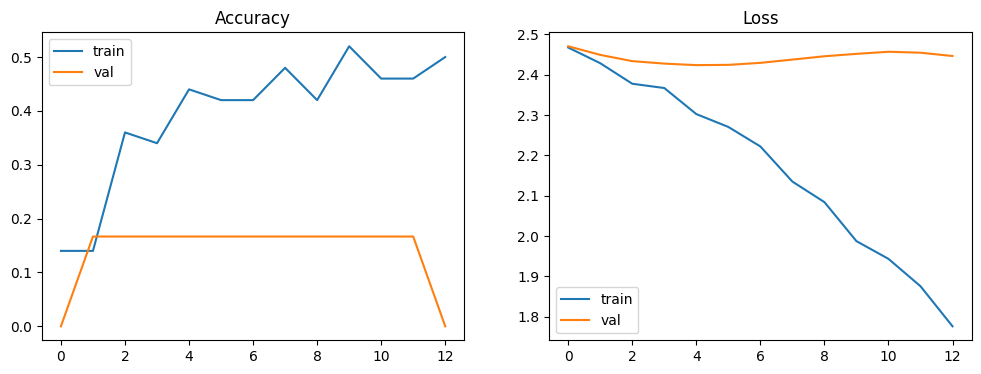

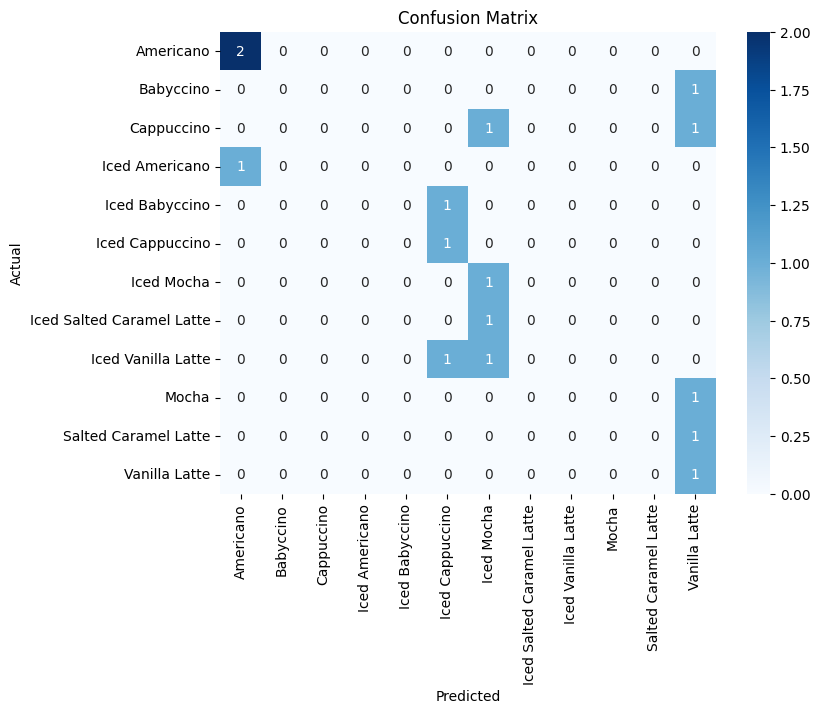

It's really hot today. I want something cold and sweet but I don't want very strong coffee.
 -> ☕ Vanilla Latte — 10% match

I need a really strong black coffee to wake up
 -> ☕ Americano — 11% match

Give me something chocolatey and creamy
 -> ☕ Vanilla Latte — 9% match

Just a plain hot coffee please, nothing fancy
 -> ☕ Babyccino — 9% match

I want something icy and refreshing but not too sugary
 -> ☕ Iced Cappuccino — 10% match



In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Re-run training but keep the history object so we can plot curves
df = load_data(DATA_PATH)
X, y, tfidf, ohe, label_encoder = build_features(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = build_ann(input_dim=X.shape[1], num_classes=y.shape[1])
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=60,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)

# 1. Plot accuracy/loss curves -- watch for train/val divergence (overfitting)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].legend()
plt.show()

# 2. Confusion matrix on the held-out test set
y_pred = model.predict(X_test, verbose=0)
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred, axis=1))
y_test_labels = label_encoder.inverse_transform(np.argmax(y_test, axis=1))

cm = confusion_matrix(y_test_labels, y_pred_labels, labels=label_encoder.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 3. Manual test cases -- try sentences NOT in the training data
test_sentences = [
    "It's really hot today. I want something cold and sweet but I don't want very strong coffee.",
    "I need a really strong black coffee to wake up",
    "Give me something chocolatey and creamy",
    "Just a plain hot coffee please, nothing fancy",
    "I want something icy and refreshing but not too sugary",
]

for t in test_sentences:
    result = ai_barista(t, model, tfidf, ohe, label_encoder, verbose=False)
    print(f"{t}\n -> {result['display']}\n")